# Flow Matching - Conditional Population of Stars

This notebook reads the tutorial conditional stellar NPZ, adds uniform Gaussian photometric noise during preprocessing, standardizes the observed CMD together with the conditioning signal `(log_tau, feh)`, and trains a simple conditional MLP with a velocity-space flow-matching loss.

The train/validation split is done at the **population_id** level so each held-out validation population is entirely unseen during training.


In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax import linen as nn
from flax.training import train_state
from matplotlib.ticker import MultipleLocator
from tqdm.auto import tqdm

plt.style.use("default")
plt.rcParams.update(
    {
        "axes.grid": False,
        "axes.linewidth": 1.1,
        "font.size": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while not (root / "environment-isochrones.yml").exists() and root != root.parent:
        root = root.parent
    return root


ROOT = find_repo_root()
DATA_PATH = ROOT / "tutorial_data" / "tutorial_conditional_population.npz"

SOURCE_REQUIRED_COLUMNS = ("G", "BP", "RP", "population_index", "log_tau", "feh")
POPULATION_TABLE_REQUIRED_COLUMNS = ("population_index", "log_tau", "feh")
CMD_OBS_COLUMNS = ("BP_minus_RP_obs", "M_G_obs")
CONDITION_COLUMNS = ("log_tau", "feh")
CMD_COLOR_COLUMN = 0
CMD_GMAG_COLUMN = 1
LOG_TAU_COLUMN = 0
FEH_COLUMN = 1

OBSERVATION_NOISE_MEAN = 0.0
OBSERVATION_NOISE_STD = 0.03
OBSERVATION_NOISE_SEED = 7

print(f"JAX backend: {jax.default_backend()}")
print(f"Primary device: {jax.devices()[0]}")
print(f"Tutorial data path: {DATA_PATH.relative_to(ROOT)}")
print("Expected source columns:", SOURCE_REQUIRED_COLUMNS)
print("Expected population table columns:", POPULATION_TABLE_REQUIRED_COLUMNS)
print("Observed CMD columns rebuilt in this notebook:", CMD_OBS_COLUMNS)
print("Condition columns:", CONDITION_COLUMNS)
print(f"Per-filter noise std: {OBSERVATION_NOISE_STD:.3f} mag")


JAX backend: cpu
Primary device: TFRT_CPU_0
Tutorial data path: tutorial_data/tutorial_conditional_population.npz
Expected source columns: ('G', 'BP', 'RP', 'population_index', 'log_tau', 'feh')
Expected population table columns: ('population_index', 'log_tau', 'feh')
Observed CMD columns rebuilt in this notebook: ('BP_minus_RP_obs', 'M_G_obs')
Condition columns: ('log_tau', 'feh')
Per-filter noise std: 0.030 mag


/Users/tr/opt/anaconda3/envs/aemu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
catalog = np.load(DATA_PATH)

raw_data = catalog["data"].astype(np.float32)
raw_columns = tuple(str(name) for name in catalog["columns"].tolist())
population_table = catalog["population_table"].astype(np.float32)
population_table_columns = tuple(str(name) for name in catalog["population_table_columns"].tolist())
catalog_seed = int(catalog["catalog_seed"])
sample_seed_start = int(catalog["sample_seed_start"])

if raw_data.ndim != 2:
    raise ValueError(f"Expected tutorial data to be 2D, got shape {raw_data.shape}.")
if raw_data.shape[1] != len(raw_columns):
    raise ValueError(
        f"Expected {len(raw_columns)} source columns, got data shape {raw_data.shape}."
    )
if population_table.ndim != 2:
    raise ValueError(f"Expected population table to be 2D, got shape {population_table.shape}.")
if population_table.shape[1] != len(population_table_columns):
    raise ValueError(
        "Population table width does not match declared population-table columns."
    )

missing_source_columns = [name for name in SOURCE_REQUIRED_COLUMNS if name not in raw_columns]
if missing_source_columns:
    raise ValueError(f"Missing required source columns: {missing_source_columns}")

missing_population_columns = [
    name for name in POPULATION_TABLE_REQUIRED_COLUMNS if name not in population_table_columns
]
if missing_population_columns:
    raise ValueError(f"Missing required population table columns: {missing_population_columns}")

column_to_index = {name: idx for idx, name in enumerate(raw_columns)}
population_table_column_to_index = {
    name: idx for idx, name in enumerate(population_table_columns)
}

g_clean = raw_data[:, column_to_index["G"]]
bp_clean = raw_data[:, column_to_index["BP"]]
rp_clean = raw_data[:, column_to_index["RP"]]
population_id = raw_data[:, column_to_index["population_index"]].astype(np.int32)
log_tau = raw_data[:, column_to_index["log_tau"]]
feh = raw_data[:, column_to_index["feh"]]

noise_rng = np.random.default_rng(OBSERVATION_NOISE_SEED)
noise_g = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)
noise_bp = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)
noise_rp = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)

g_obs = (g_clean + noise_g).astype(np.float32)
bp_obs = (bp_clean + noise_bp).astype(np.float32)
rp_obs = (rp_clean + noise_rp).astype(np.float32)

bp_rp_obs = (bp_obs - rp_obs).astype(np.float32)
M_G_obs = g_obs.copy()

cmd_observed = np.column_stack([bp_rp_obs, M_G_obs]).astype(np.float32)
conditioning = np.column_stack([log_tau, feh]).astype(np.float32)

unique_population_ids = population_table[
    :, population_table_column_to_index["population_index"]
].astype(np.int32)
population_log_tau = population_table[:, population_table_column_to_index["log_tau"]].astype(np.float32)
population_feh = population_table[:, population_table_column_to_index["feh"]].astype(np.float32)
population_conditioning = np.column_stack([population_log_tau, population_feh]).astype(np.float32)

if not np.array_equal(np.unique(population_id), unique_population_ids):
    raise ValueError("Population ids in the data and population table do not match.")

population_id_width = max(3, len(str(len(unique_population_ids) - 1)))

print(f"Catalog size:            {len(raw_data):,}")
print(f"Number of populations:   {len(unique_population_ids):,}")
print("Stored columns:         ", raw_columns)
print("Population-table cols:  ", population_table_columns)
print(f"Catalog seed:            {catalog_seed}")
print(f"Sample seed start:       {sample_seed_start}")
print()
print("Tutorial generator assumptions used here: distance_pc = 10.0, AV = 0.0")
print("That means the stored G magnitude is already M_G.")
print()
print(f"Observed color range:    {bp_rp_obs.min():.3f} .. {bp_rp_obs.max():.3f}")
print(f"Observed M_G range:      {M_G_obs.min():.3f} .. {M_G_obs.max():.3f}")
print(f"log_tau range:           {log_tau.min():.3f} .. {log_tau.max():.3f}")
print(f"[Fe/H] range:            {feh.min():.3f} .. {feh.max():.3f}")


Catalog size:            100,000
Number of populations:   1,000
Stored columns:          ('G', 'BP', 'RP', 'population_index', 'log_tau', 'feh')
Population-table cols:   ('population_index', 'log_tau', 'feh')
Catalog seed:            11
Sample seed start:       10000

Tutorial generator assumptions used here: distance_pc = 10.0, AV = 0.0
That means the stored G magnitude is already M_G.

Observed color range:    -0.604 .. 4.345
Observed M_G range:      -3.089 .. 7.434
log_tau range:           9.002 .. 9.799
[Fe/H] range:            -0.500 .. 0.249


In [3]:
val_fraction = 0.10
split_seed = 42

split_rng = np.random.default_rng(split_seed)
shuffled_population_ids = unique_population_ids.copy()
split_rng.shuffle(shuffled_population_ids)

n_val_populations = int(val_fraction * len(unique_population_ids))
val_population_ids = np.sort(shuffled_population_ids[:n_val_populations])
train_population_ids = np.sort(shuffled_population_ids[n_val_populations:])

train_population_mask = np.isin(unique_population_ids, train_population_ids)
val_population_mask = np.isin(unique_population_ids, val_population_ids)
train_mask = np.isin(population_id, train_population_ids)
val_mask = np.isin(population_id, val_population_ids)

x_train = cmd_observed[train_mask]
x_val = cmd_observed[val_mask]

condition_train = conditioning[train_mask]
condition_val = conditioning[val_mask]

train_population_condition = population_conditioning[train_population_mask]

x_mean = x_train.mean(axis=0)
x_std = x_train.std(axis=0)
cond_mean = train_population_condition.mean(axis=0)
cond_std = train_population_condition.std(axis=0)

if np.any(x_std <= 0.0):
    raise ValueError(f"Non-positive CMD standard deviation encountered: {x_std}")
if np.any(cond_std <= 0.0):
    raise ValueError(f"Non-positive condition standard deviation encountered: {cond_std}")

x_train_standardized = ((x_train - x_mean) / x_std).astype(np.float32)
x_val_standardized = ((x_val - x_mean) / x_std).astype(np.float32)
condition_train_standardized = ((condition_train - cond_mean) / cond_std).astype(np.float32)
condition_val_standardized = ((condition_val - cond_mean) / cond_std).astype(np.float32)

train_array = x_train_standardized.astype(np.float32)
val_array = x_val_standardized.astype(np.float32)
train_condition_array = condition_train_standardized.astype(np.float32)
val_condition_array = condition_val_standardized.astype(np.float32)

print(f"Train populations:       {len(train_population_ids):,}")
print(f"Validation populations:  {len(val_population_ids):,}")
print(f"Train stars:             {len(x_train):,}")
print(f"Validation stars:        {len(x_val):,}")
print()
print("Observed-data mean:", x_mean)
print("Observed-data std: ", x_std)
print("Condition mean:    ", cond_mean)
print("Condition std:     ", cond_std)


Train populations:       900
Validation populations:  100
Train stars:             90,000
Validation stars:        10,000

Observed-data mean: [0.8024838 4.5483813]
Observed-data std:  [0.25887018 1.4191276 ]
Condition mean:     [ 9.388882   -0.12883928]
Condition std:      [0.22889796 0.21383458]


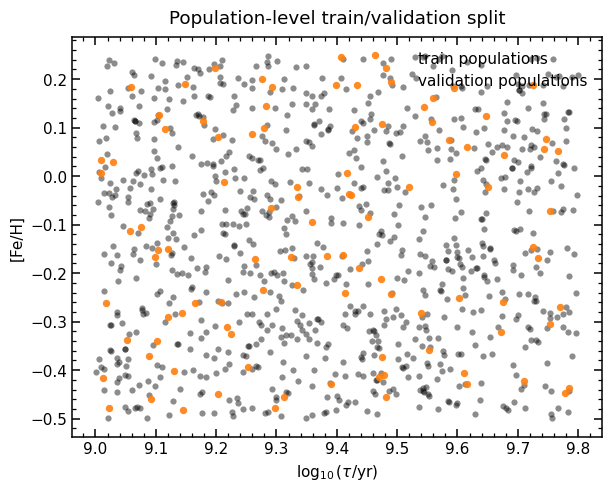

In [4]:
fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)

ax.scatter(
    population_conditioning[train_population_mask, LOG_TAU_COLUMN],
    population_conditioning[train_population_mask, FEH_COLUMN],
    s=20,
    alpha=0.45,
    color="black",
    linewidths=0,
    label="train populations",
    rasterized=True,
)
ax.scatter(
    population_conditioning[val_population_mask, LOG_TAU_COLUMN],
    population_conditioning[val_population_mask, FEH_COLUMN],
    s=28,
    alpha=0.90,
    color="tab:orange",
    linewidths=0,
    label="validation populations",
    rasterized=True,
)

ax.set_xlabel(r"$\log_{10}(\tau / \mathrm{yr})$")
ax.set_ylabel(r"[Fe/H]")
ax.set_title("Population-level train/validation split", pad=10)
ax.grid(False)
ax.legend(frameon=False)

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.xaxis.set_minor_locator(MultipleLocator(0.02))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.02))

ax.tick_params(which="major", length=6, width=1.1)
ax.tick_params(which="minor", length=3, width=0.9)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

plt.show()


We now train on the **standardized observed CMD** `x`, while also providing the standardized conditioning vector

$$
c = (\log_{10}(\tau / \mathrm{yr}), [\mathrm{Fe}/\mathrm{H}]).
$$

For each batch point `x`, condition `c`, and Gaussian noise draw `e`, the bridge is

$$
z_t = t x + (1 - t) e.
$$

The neural network predicts a point in the same CMD coordinates,

$$
\hat{x}_\theta(z_t, t, c),
$$

which induces the velocity field

$$
v_\theta(z_t, t, c) = \frac{\hat{x}_\theta(z_t, t, c) - z_t}{1 - t}.
$$

We keep the same velocity target and loss:

$$
v^*(x, e) = x - e,
$$

$$
\mathcal{L}_v = \mathbb{E}\left[\|v^*(x, e) - v_\theta(z_t, t, c)\|^2\right].
$$


In [5]:
class ConditionalFlowMLP(nn.Module):
    hidden_dim: int = 256
    output_dim: int = 2
    n_linear_layers: int = 5

    @nn.compact
    def __call__(self, z: jnp.ndarray, t: jnp.ndarray, c: jnp.ndarray) -> jnp.ndarray:
        if self.n_linear_layers < 2:
            raise ValueError("n_linear_layers must be at least 2.")

        hidden = jnp.concatenate([z, t, c], axis=-1)
        for _ in range(self.n_linear_layers - 1):
            hidden = nn.Dense(
                self.hidden_dim,
                kernel_init=nn.initializers.glorot_uniform(),
                bias_init=nn.initializers.zeros_init(),
            )(hidden)
            hidden = jax.nn.relu(hidden)

        return nn.Dense(
            self.output_dim,
            kernel_init=nn.initializers.glorot_uniform(),
            bias_init=nn.initializers.zeros_init(),
        )(hidden)


def count_parameters(params) -> int:
    return sum(leaf.size for leaf in jax.tree_util.tree_leaves(params))


def make_learning_rate_schedule(
    learning_rate: float,
    train_steps: int,
    warmup_fraction: float,
):
    warmup_steps = max(1, int(train_steps * warmup_fraction))
    cosine_steps = max(train_steps - warmup_steps, 1)
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=learning_rate,
        warmup_steps=warmup_steps,
        decay_steps=cosine_steps,
        end_value=0.0,
    )
    return schedule, warmup_steps, cosine_steps


def build_fixed_validation_targets(
    data_array: np.ndarray,
    seed: int,
    time_mu: float,
    time_sigma: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    logit_t = time_mu + time_sigma * rng.standard_normal((len(data_array), 1)).astype(np.float32)
    t = (1.0 / (1.0 + np.exp(-logit_t))).astype(np.float32)
    e = rng.normal(size=data_array.shape).astype(np.float32)
    z = (t * data_array + (1.0 - t) * e).astype(np.float32)
    v_target = (data_array - e).astype(np.float32)
    return z, t, v_target


In [6]:
HIDDEN_DIM = 256
N_LINEAR_LAYERS = 4
TRAIN_STEPS = 10_000
BATCH_SIZE = 1024
LEARNING_RATE = 5.0e-3
LR_WARMUP_FRACTION = 0.10
TIME_MU = -0.8
TIME_SIGMA = 0.8
DENOM_CLIP = 0.05
VAL_BATCH_SIZE = 1024
VAL_EVERY = 256
FIXED_VAL_SEED = 123

learning_rate_schedule, warmup_steps, cosine_steps = make_learning_rate_schedule(
    learning_rate=LEARNING_RATE,
    train_steps=TRAIN_STEPS,
    warmup_fraction=LR_WARMUP_FRACTION,
)

model = ConditionalFlowMLP(
    hidden_dim=HIDDEN_DIM,
    output_dim=train_array.shape[1],
    n_linear_layers=N_LINEAR_LAYERS,
)

rng = jax.random.PRNGKey(7)
rng, init_rng = jax.random.split(rng)

initial_params = model.init(
    init_rng,
    jnp.ones((1, train_array.shape[1]), dtype=jnp.float32),
    jnp.ones((1, 1), dtype=jnp.float32),
    jnp.ones((1, train_condition_array.shape[1]), dtype=jnp.float32),
)["params"]

state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=initial_params,
    tx=optax.adam(learning_rate=learning_rate_schedule),
)

val_z_fixed, val_t_fixed, val_v_target_fixed = build_fixed_validation_targets(
    val_array,
    seed=FIXED_VAL_SEED,
    time_mu=TIME_MU,
    time_sigma=TIME_SIGMA,
)


def predict_x(params, z: jnp.ndarray, t: jnp.ndarray, c: jnp.ndarray) -> jnp.ndarray:
    return model.apply({"params": params}, z, t, c)


@jax.jit
def train_step(state, x, c, rng):
    rng_t, rng_e = jax.random.split(rng)

    def loss_fn(params) -> jax.Array:
        logit_t = TIME_MU + TIME_SIGMA * jax.random.normal(rng_t, (x.shape[0], 1), dtype=x.dtype)
        t = jax.nn.sigmoid(logit_t)

        e = jax.random.normal(rng_e, x.shape, dtype=x.dtype)
        z = t * x + (1.0 - t) * e
        raw = state.apply_fn({"params": params}, z, t, c)

        v_target = x - e
        v_pred = (raw - z) / jnp.clip(1.0 - t, a_min=DENOM_CLIP)
        return jnp.mean((v_target - v_pred) ** 2)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss


@jax.jit
def eval_batch(params, z, t, c, v_target):
    raw = predict_x(params, z, t, c)
    v_pred = (raw - z) / jnp.clip(1.0 - t, a_min=DENOM_CLIP)
    return jnp.mean((v_target - v_pred) ** 2)


def estimate_validation_loss(
    params,
    val_z: np.ndarray,
    val_t: np.ndarray,
    val_c: np.ndarray,
    val_v_target: np.ndarray,
    batch_size: int = VAL_BATCH_SIZE,
) -> float:
    losses = []
    for batch_start in range(0, len(val_z), batch_size):
        batch_stop = min(batch_start + batch_size, len(val_z))
        z_batch = jnp.asarray(val_z[batch_start:batch_stop])
        t_batch = jnp.asarray(val_t[batch_start:batch_stop])
        c_batch = jnp.asarray(val_c[batch_start:batch_stop])
        v_batch = jnp.asarray(val_v_target[batch_start:batch_stop])
        losses.append(float(eval_batch(params, z_batch, t_batch, c_batch, v_batch)))
    return float(np.mean(losses))


### Run training

Validation is deterministic in this notebook: the bridge times and bridge noise for the validation set are sampled **once** with `FIXED_VAL_SEED = 123` and then reused for every validation call.


In [7]:
history = {
    "step": [],
    "train_loss": [],
    "val_step": [],
    "val_loss": [],
    "lr": [],
}

batch_rng = np.random.default_rng(7)
best_val_loss = float("inf")
best_step = None
best_params = state.params

print(f"Model:                  {type(model).__name__}")
print(f"Trainable parameters:   {count_parameters(state.params):,}")
print(f"Batch size:             {BATCH_SIZE}")
print(f"Train steps:            {TRAIN_STEPS}")
print(f"Warmup steps:           {warmup_steps}")
print(f"Cosine-decay steps:     {cosine_steps}")
print(f"Validation every:       {VAL_EVERY}")
print(f"Fixed validation seed:  {FIXED_VAL_SEED}")
print(f"Time sampler:           sigmoid({TIME_MU} + {TIME_SIGMA} * N(0, 1))")
print(f"Denominator clip:       {DENOM_CLIP}")

progress = tqdm(range(1, TRAIN_STEPS + 1), desc="Training", leave=False)
for step in progress:
    batch_idx = batch_rng.integers(0, len(train_array), size=BATCH_SIZE)
    x_batch = jnp.asarray(train_array[batch_idx])
    c_batch = jnp.asarray(train_condition_array[batch_idx])

    rng, step_rng = jax.random.split(rng)
    state, loss = train_step(state, x_batch, c_batch, step_rng)

    loss_value = float(loss)
    lr_value = float(learning_rate_schedule(int(state.step)))

    history["step"].append(step)
    history["train_loss"].append(loss_value)
    history["lr"].append(lr_value)

    if step == 1 or step % VAL_EVERY == 0 or step == TRAIN_STEPS:
        val_loss = estimate_validation_loss(
            state.params,
            val_z_fixed,
            val_t_fixed,
            val_condition_array,
            val_v_target_fixed,
        )
        history["val_step"].append(step)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_step = step
            best_params = state.params

        progress.set_postfix(train=f"{loss_value:.4f}", val=f"{val_loss:.4f}", lr=f"{lr_value:.2e}")
    elif step % 50 == 0:
        progress.set_postfix(train=f"{loss_value:.4f}", lr=f"{lr_value:.2e}")

print()
print(f"Best validation step:   {best_step}")
print(f"Best validation loss:   {best_val_loss:.5f}")


Model:                  ConditionalFlowMLP
Trainable parameters:   133,634
Batch size:             1024
Train steps:            10000
Warmup steps:           1000
Cosine-decay steps:     9000
Validation every:       256
Fixed validation seed:  123
Time sampler:           sigmoid(-0.8 + 0.8 * N(0, 1))
Denominator clip:       0.05



Best validation step:   6656
Best validation loss:   1.28125


### Summarise training


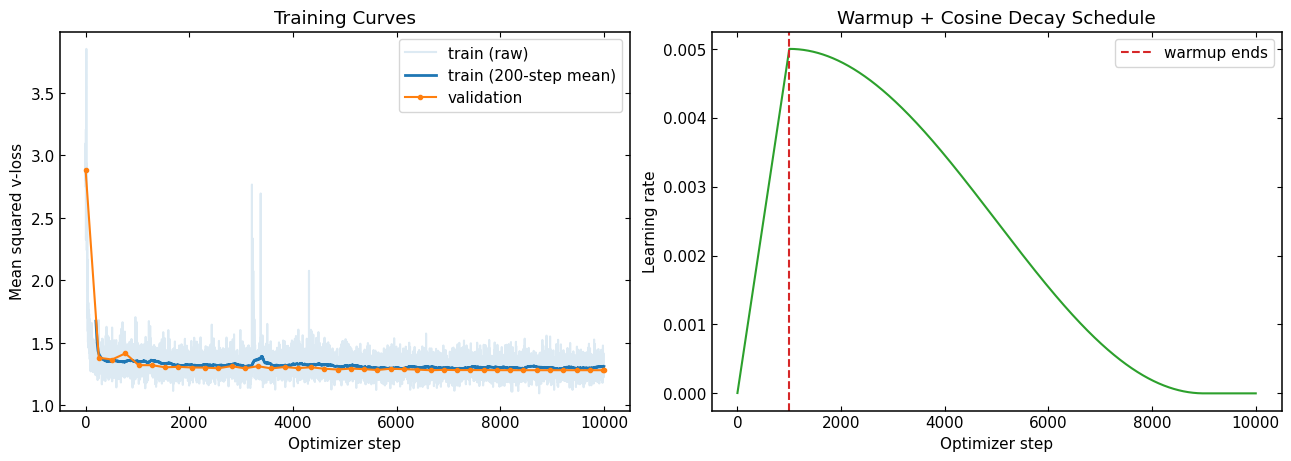

In [8]:
steps = np.asarray(history["step"])
train_losses = np.asarray(history["train_loss"])
val_steps = np.asarray(history["val_step"])
val_losses = np.asarray(history["val_loss"])
learning_rates = np.asarray(history["lr"])

smooth_window = min(200, len(train_losses))
if smooth_window > 1:
    smooth_kernel = np.ones(smooth_window, dtype=np.float64) / smooth_window
    train_losses_smooth = np.convolve(train_losses, smooth_kernel, mode="valid")
    smooth_steps = steps[smooth_window - 1 :]
else:
    train_losses_smooth = train_losses
    smooth_steps = steps

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5), constrained_layout=True)

axes[0].plot(steps, train_losses, color="tab:blue", alpha=0.15, label="train (raw)")
axes[0].plot(
    smooth_steps,
    train_losses_smooth,
    color="tab:blue",
    linewidth=2,
    label=f"train ({smooth_window}-step mean)",
)
axes[0].plot(val_steps, val_losses, color="tab:orange", marker="o", markersize=3, label="validation")
axes[0].set_xlabel("Optimizer step")
axes[0].set_ylabel("Mean squared v-loss")
axes[0].set_title("Training Curves")
axes[0].legend()

axes[1].plot(steps, learning_rates, color="tab:green")
axes[1].axvline(warmup_steps, color="tab:red", linestyle="--", linewidth=1.5, label="warmup ends")
axes[1].set_xlabel("Optimizer step")
axes[1].set_ylabel("Learning rate")
axes[1].set_title("Warmup + Cosine Decay Schedule")
axes[1].legend()

plt.show()


## Visual validation

We choose one held-out validation population, keep its `(log_tau, feh)` fixed, and generate a synthetic CMD from Gaussian noise using the learned conditional flow.


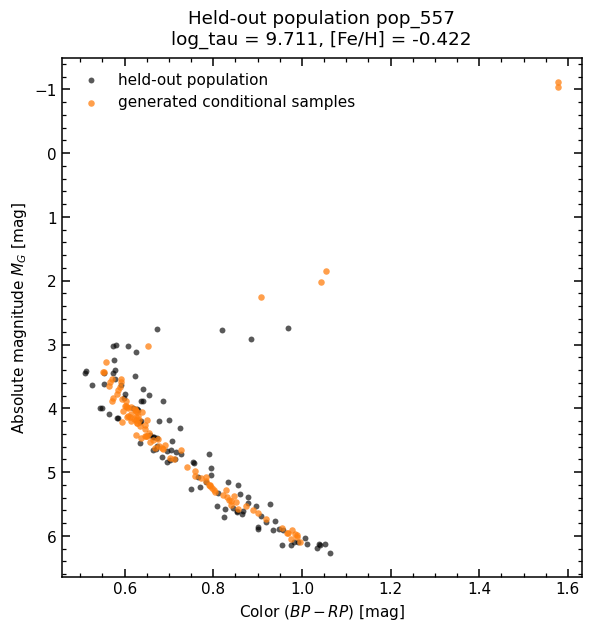

In [9]:
INTEGRATION_STEPS = 300
SAMPLING_SEED = 321
HELDOUT_POPULATION_POSITION = len(val_population_ids) // 2


@jax.jit
def predict_velocity(params, z, t, c):
    raw = predict_x(params, z, t, c)
    return (raw - z) / jnp.clip(1.0 - t, a_min=DENOM_CLIP)


def integrate_learned_flow(params, x0, c, n_steps=INTEGRATION_STEPS):
    z = jnp.asarray(x0, dtype=jnp.float32)
    c = jnp.asarray(c, dtype=jnp.float32)
    dt = np.float32(1.0 / n_steps)

    for step in range(n_steps):
        t_value = np.float32(step / n_steps)
        t_batch = jnp.full((z.shape[0], 1), t_value, dtype=z.dtype)
        z = z + dt * predict_velocity(params, z, t_batch, c)

    return np.asarray(z, dtype=np.float32)


heldout_population_id = int(val_population_ids[HELDOUT_POPULATION_POSITION])
heldout_population_label = f"pop_{heldout_population_id:0{population_id_width}d}"
heldout_population_mask = population_id == heldout_population_id

heldout_cmd = cmd_observed[heldout_population_mask]
heldout_condition = conditioning[heldout_population_mask][0]
heldout_condition_standardized = ((heldout_condition - cond_mean) / cond_std).astype(np.float32)

sample_rng = np.random.default_rng(SAMPLING_SEED)
x0_samples = sample_rng.normal(size=heldout_cmd.shape).astype(np.float32)
heldout_condition_batch = np.repeat(
    heldout_condition_standardized[None, :],
    len(heldout_cmd),
    axis=0,
).astype(np.float32)

params_for_sampling = best_params if best_step is not None else state.params
generated_standardized = integrate_learned_flow(
    params_for_sampling,
    x0_samples,
    heldout_condition_batch,
)
generated_cmd = (generated_standardized * x_std + x_mean).astype(np.float32)

fig, ax = plt.subplots(figsize=(5.8, 6.2), constrained_layout=True)

ax.scatter(
    heldout_cmd[:, CMD_COLOR_COLUMN],
    heldout_cmd[:, CMD_GMAG_COLUMN],
    s=18,
    alpha=0.65,
    color="black",
    linewidths=0,
    label="held-out population",
)
ax.scatter(
    generated_cmd[:, CMD_COLOR_COLUMN],
    generated_cmd[:, CMD_GMAG_COLUMN],
    s=22,
    alpha=0.75,
    color="tab:orange",
    linewidths=0,
    label="generated conditional samples",
)

ax.set_xlabel(r"Color $(BP - RP)$ [mag]")
ax.set_ylabel(r"Absolute magnitude $M_G$ [mag]")
ax.set_title(
    (
        f"Held-out population {heldout_population_label}\n"
        f"log_tau = {heldout_condition[LOG_TAU_COLUMN]:.3f}, [Fe/H] = {heldout_condition[FEH_COLUMN]:.3f}"
    ),
    pad=10,
)
ax.invert_yaxis()
ax.grid(False)
ax.legend(loc="upper left", frameon=False)

ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(1.0))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

ax.tick_params(which="major", length=6, width=1.1)
ax.tick_params(which="minor", length=3, width=0.9)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

plt.show()
